In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

## Combine a specific number of LCDM with a specific number of beyond-LCDM sims

In [2]:
all_BSQ_Pks = np.load('../Pk_files/all_Pk_BSQ.npy')
print(len(all_BSQ_Pks))
all_BSQ_params = np.loadtxt('../../real_params/all_BSQ_params.txt')
print(len(all_BSQ_params))

cosm_type = 'nwLH'
Pk_type = 'MPk'
param_ext = ''
all_cosm_Pks = np.load('../Pk_files/all_'+Pk_type+'_'+cosm_type+param_ext +'.npy')
print(len(all_cosm_Pks))
all_cosm_params = np.loadtxt('../../real_params/all_'+cosm_type+'_params'+param_ext+'.txt')
print((all_cosm_params).shape)

32000
32000
2000
(2000, 7)


In [3]:
# all_BSQ_Pks = np.load('../Pk_files/all_Pk_BSQ.npy')
# all_BSQ_params = np.loadtxt('../../real_params/' + 'all_BSQ_params.txt')
# print(all_BSQ_Pks.shape)
# print(all_BSQ_params.shape)

# cosm_type = 'nwLH'
# Pk_type = 'MPk'
# param_ext = ''
# all_cosm_Pks = np.load('../Pk_files/'+'all_'+Pk_type+'_'+cosm_type+param_ext +'.npy')
# all_cosm_params = np.loadtxt('real_params/' + 'all_'+cosm_type+'_params'+param_ext+'.txt')
# print(all_cosm_Pks.shape)
# print(all_cosm_params.shape)


def save_combined_datasets(n_pre, n_ft, seed=42):
    # 1. Get Indices
    def get_indices(total, s):
        idx = np.arange(total)
        np.random.seed(s)
        np.random.shuffle(idx)
        return idx


    # 2. Load Raw Data 
    all_BSQ_Pks = np.load('../Pk_files/all_Pk_BSQ.npy')
    all_BSQ_params = np.loadtxt('../../real_params/all_BSQ_params.txt')

    # Add a 6th column of 0s (Assuming all_BSQ_params is (32000, 5))
    padding = np.zeros((all_BSQ_params.shape[0], 1))
    all_BSQ_params_6col = np.hstack((all_BSQ_params, padding))
    
    all_cosm_Pks = np.load('../Pk_files/all_'+Pk_type+'_'+cosm_type+param_ext +'.npy')
    all_cosm_params = np.loadtxt('../../real_params/all_'+cosm_type+'_params'+param_ext+'.txt')
    # Keep only the first 6 columns (Assuming all_cosm_params is (2000, 7))
    all_cosm_params_6col = all_cosm_params[:, :6]

    n_BSQ_Pks = len(all_BSQ_Pks)
    n_cosm_Pks = len(all_cosm_Pks)
    idx_BSQ = get_indices(n_BSQ_Pks, seed)
    idx_cosm = get_indices(n_cosm_Pks, seed)

    # 3. Create TRAIN (Combined)
    # Get 22,000 LCDM training samples
    train_idx_BSQ = idx_BSQ[0 : int(n_BSQ_Pks*0.7)][:n_pre]
    # Get n_ft beyond-LCDM training samples
    train_idx_cosm = idx_cosm[0 : int(n_cosm_Pks*0.7)][:n_ft]

    train_pk = np.concatenate([all_BSQ_Pks[train_idx_BSQ], all_cosm_Pks[train_idx_cosm]], axis=0)
    train_pars = np.concatenate([all_BSQ_params_6col[train_idx_BSQ], all_cosm_params_6col[train_idx_cosm]], axis=0)

    # Shuffle the training set together
    # p = np.random.permutation(len(train_pk))
    np.save('Pk_files/'+Pk_type+'_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_train.npy', train_pk)
    np.savetxt('real_params/'+Pk_type+'_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_params_train.txt', train_pars)

    # 4. Create VALIDATION (Combined)
    # Beyond-LCDM indices (15%)
    v_size_cosm, v_off_cosm =  int(n_cosm_Pks*0.15), int(n_cosm_Pks*0.70)
    t_size_cosm, t_off_cosm =  int(n_cosm_Pks*0.15), int(n_cosm_Pks*0.85)

    valid_idx_cosm = idx_cosm[v_off_cosm : v_off_cosm + v_size_cosm]
    test_idx_cosm  = idx_cosm[t_off_cosm : t_off_cosm + t_size_cosm]

    # BSQ indices (The remaining 30%, split into 15% valid and 15% test)
    v_size_BSQ, v_off_BSQ = int(n_BSQ_Pks*0.15), int(n_BSQ_Pks*0.70)
    t_size_BSQ, t_off_BSQ =  int(n_BSQ_Pks*0.15), int(n_BSQ_Pks*0.85)
     
    valid_idx_BSQ = idx_BSQ[v_off_BSQ : v_off_BSQ + v_size_BSQ]

    # Concatenate Beyond-LCDM and LCDM for Validation
    valid_pk = np.concatenate([all_cosm_Pks[valid_idx_cosm], all_BSQ_Pks[valid_idx_BSQ]], axis=0)
    valid_pars = np.concatenate([all_cosm_params_6col[valid_idx_cosm], all_BSQ_params_6col[valid_idx_BSQ]], axis=0)


    np.save('Pk_files/'+Pk_type+'_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_valid.npy', valid_pk)
    np.savetxt('real_params/'+Pk_type+'_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_params_valid.txt', valid_pars)
    
    np.save('Pk_files/'+cosm_type+'_'+Pk_type+'_test.npy', all_cosm_Pks[test_idx_cosm])
    np.savetxt('real_params/'+cosm_type+'_'+Pk_type+'_params_test.txt', all_cosm_params_6col[test_idx_cosm])

    print(f"Files saved for N_pre={n_pre}, N_ft={n_ft}")


In [5]:
##Example: generate the comparison for 22k pre-trained + 800 fine-tuned
# save_combined_datasets(22000, 1400)
save_combined_datasets(n_pre = 2000, n_ft = 1400, seed=42)
save_combined_datasets(n_pre = 2000, n_ft =800, seed=42)
save_combined_datasets(n_pre = 2000, n_ft =400, seed=42)
save_combined_datasets(n_pre = 2000, n_ft =200, seed=42)
save_combined_datasets(n_pre = 2000, n_ft =100, seed=42)
save_combined_datasets(n_pre = 2000, n_ft =50, seed=42)

Files saved for N_pre=2000, N_ft=1400
Files saved for N_pre=2000, N_ft=800
Files saved for N_pre=2000, N_ft=400
Files saved for N_pre=2000, N_ft=200
Files saved for N_pre=2000, N_ft=100
Files saved for N_pre=2000, N_ft=50


In [10]:
n_ft = 100
n_pre= 22000

Pk_train = np.load('Pk_files/Pk_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_train.npy')
params_train = np.loadtxt('real_params/Pk_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_params_train.txt')

Pk_valid = np.load('Pk_files/Pk_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_valid.npy')
params_valid = np.loadtxt('real_params/Pk_'+str(n_ft)+'_'+cosm_type+'_'+str(n_pre)+'_BSQ_combined_params_valid.txt')

Pk_test = np.load('Pk_files/'+cosm_type+'_'+Pk_type+'_test.npy')
params_test = np.loadtxt('real_params/'+cosm_type+'_'+Pk_type+'_params_test.txt')

print(Pk_train.shape)
print(params_train.shape)
print(Pk_valid.shape)
print(params_valid.shape)
print(Pk_test.shape)
print(params_test.shape)

(22100, 79)
(22100, 6)
(4950, 79)
(4950, 6)
(150, 79)
(150, 6)


# Get Pks

(2000, 7)
(2000, 79)
(2000, 7)


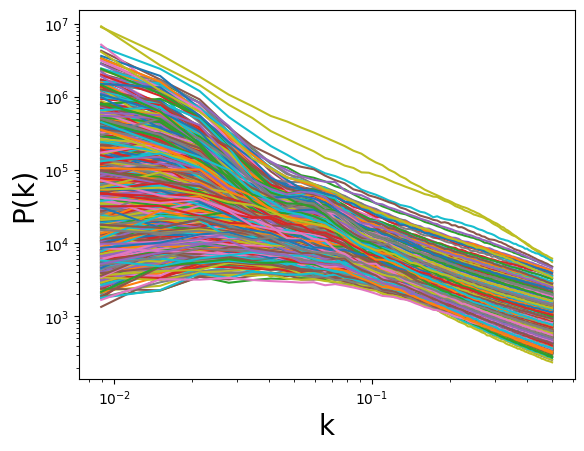

In [17]:

k_max = 0.5
Pk_type = 'Pk'
cosm_type = 'nwLH'
# param_ext = '_lcdm'
param_ext = ''
file_path = '/scratch/network/vk9342/latin_hypercube_'+Pk_type+'_'+cosm_type+'/'
# file_path = '/scratch/network/vk9342/BSQ/'


# file_name = '/Pk_CDM+NU_z=0.000.dat'   #fR
# file_name = '/Pk_CDM_z=0.000.dat' # EQ
# file_name = '/Pk_CDM_z=0.000.dat' # LC
# file_name = '/Pk_m_z=0.txt'  #nwLH
# file_name = '/Pk_m_z0.dat' #BSQ

# file_name = '/Pk_m_marked_fTH_R10.0_p2.0_ds0.25_z0.txt'
file_name = '/Pk_m_z=0.txt'  #nwLH Pk
# file_name = '/Pk_CDM_z=0.000.dat' #BSQ



all_params  = np.loadtxt('real_params/all_'+cosm_type+'_params'+param_ext+'.txt')
print(all_params.shape)

n_sims_total = len(all_params)

params_filtered = []
Pks = []
ks = []
for i in range(n_sims_total):
    Pk_file = file_path+str(i)+file_name
    # print(Pk_file)
    if os.path.exists(Pk_file): 
        # params_filtered.append(all_params[i])
        data = np.loadtxt(file_path+str(i)+file_name, unpack=True) #load file of index 
        Pk = data[1, :]
        k = data[0, :]
        Pk_filtered = []
        k_filtered = []
        for j in range (len(Pk)):  #loop through Pk values from one Pk file
            if k[j] <= k_max:
                Pk_filtered.append(Pk[j])  #get Pks with corresponding k values less than k_max
                k_filtered.append(k[j])
        Pks.append(Pk_filtered)   
    else:
        print(i)

    plt.loglog(k_filtered, Pk_filtered)
    plt.ylabel('P(k)', size = 20)
    plt.xlabel('k', size = 20)
    # plt.plot(k_filtered, Pk_filtered)
    # plt.title(Pk_type)
    # print (np.sum(np.array(Pk_filtered) < 0))

# params_filtered = np.array(params_filtered)
Pks = np.array(Pks)   #Pks from all Pk files

# np.savetxt('real_params/' + 'all_'+cosm_type+'_params'+param_ext+'.txt', params_filtered, fmt='%.14f')

param_ext = ''

# np.save('Pk_files/'+'all_'+Pk_type+'_'+cosm_type+param_ext, Pks)
# print('Pk_files/'+'all_'+Pk_type+'_'+cosm_type+param_ext)
print(Pks.shape)
print(all_params.shape)

## Get n (200, 4000, 800...) sims from total N (2000) sims

In [10]:
n_sims = 2048
num_samples = 175
cosm_type = 'fR'
Pk_type = 'Pk'
param_ext = '_lcdm'

k_max = 0.5

file_path = '/scratch/network/vk9342/'+Pk_type+'_'+cosm_type+'/'
file_name = '/Pk_CDM+NU_z=0.000.dat'
all_params  = np.loadtxt('../real_params/'+cosm_type+'_params'+param_ext+'.txt')
print(all_params.shape)
# all_params = all_params[:, :6]
# print(all_params[0])

params = []
Pks = []
ks = []

for i in range(n_sims):
    Pk_file = file_path+str(i)+file_name
    if os.path.exists(Pk_file): 
        params.append(all_params[i])
        data = np.loadtxt(Pk_file, unpack=True) #load file of index 
        Pk = data[1, :]
        k = data[0, :]
        Pk_filtered = []
        k_filtered = []
        for j in range (len(Pk)):  #loop through Pk values from one Pk file
            if k[j] <= k_max:
                Pk_filtered.append(Pk[j])  #get Pks with corresponding k values less than k_max
                k_filtered.append(k[j])
        Pks.append(Pk_filtered)   
    else:
        print(i)
        print(Pk_file)

Pks = np.array(Pks)
params = np.array(params)
print(Pks.shape)
print(params.shape)

selected_indices = np.random.choice(len(Pks), num_samples, replace=False)
Pks_selected = np.array([Pks[i] for i in selected_indices])
params_selected = np.array([params[i] for i in selected_indices])

# params_selected[:, 4] = params_selected[:, 7]  #use GR sigma8
# params_selected = np.array (params_selected[:, :7])

print(Pks_selected.shape)
print(params_selected.shape)

np.save('Pk_files/'+str(num_samples)+'_'+Pk_type+'_'+cosm_type, Pks_selected)
np.savetxt('../real_params/'+str(num_samples)+'_'+cosm_type+'_'+Pk_type+'_params'+param_ext+'.txt', params_selected)




(2048, 7)
(2048, 79)
(2048, 7)
(175, 79)
(175, 7)


all_params  = np.loadtxt('../real_params/'+cosm_type+'_params.txt')
print(all_params.shape)
all_params = all_params[:, 1:]
all_params[:, 4] = all_params[:, 7]  #use GR sigma8
all_params = np.array (all_params[:, :7])
all_sigma8 = all_params[:, 4]

counter = 0
print(all_sigma8.shape)
for i in range(len(all_sigma8)):
    if all_sigma8[i] > 1.0:
        counter = counter+1

print(max(all_sigma8))
print(counter)

### combine bsq and nwLH

In [22]:
k_max = 0.5
cosm_type = 'BSQ'
Pk_type = 'Pk'

file_path_BSQ = '/scratch/network/vk9342/Pk_BSQ/'
file_name_BSQ = '/Pk_m_z0.dat'
params_BSQ  = np.loadtxt('../real_params/BSQ_params.txt')
print(params_BSQ.shape)
zeros_column = np.zeros((params_BSQ.shape[0], 1))
params_w_zeros_BSQ = np.hstack((params_BSQ, zeros_column))
print(params_w_zeros_BSQ.shape)


file_path_nwLH = '/scratch/network/vk9342/Pk_nwLH/'
file_name_nwLH = '/Pk_m_z=0.txt'
params_nwLH  = np.loadtxt('../real_params/nwLH_params.txt')
params_nwLH = params_nwLH[:, :-1]
print(params_nwLH.shape)

Pks_nwLH = []
k_nwLH = []
params_filtered_nwLH = []
for i in range(2000):
    file_nwLH = file_path_nwLH+str(i)+file_name_nwLH
    if os.path.exists(file_nwLH): 
        params_filtered_nwLH.append(params_nwLH[i])
        data_nwLH = np.loadtxt(file_path_nwLH+str(i)+file_name_nwLH, unpack=True) #load file of index 
        Pk_nwLH = data_nwLH[1, :]
        k_nwLH = data_nwLH[0, :]
        Pk_filtered_nwLH = []
        k_filtered_nwLH = []
        for j in range (len(Pk_nwLH)):  #loop through Pk values from one Pk file
            if k_nwLH[j] <= k_max:
                Pk_filtered_nwLH.append(Pk_nwLH[j])  #get Pks with corresponding k values less than k_max
                k_filtered_nwLH.append(k_nwLH[j])
        Pks_nwLH.append(Pk_filtered_nwLH)   
    else:
        print(i)

Pks_BSQ = []
k_BSQ = []
params_filtered_BSQ = []
for i in range(32768):
    file_BSQ = file_path_BSQ+str(i)+file_name_BSQ
    if os.path.exists(file_BSQ): 
        params_filtered_BSQ.append(params_w_zeros_BSQ[i])
        data_BSQ = np.loadtxt(file_path_BSQ+str(i)+file_name_BSQ, unpack=True) #load file of index 
        Pk_BSQ = data_BSQ[1, :]
        k_BSQ = data_BSQ[0, :]
        Pk_filtered_BSQ = []
        k_filtered_BSQ= []
        for j in range (len(Pk_BSQ)):  #loop through Pk values from one Pk file
            if k_BSQ[j] <= k_max:
                Pk_filtered_BSQ.append(Pk_BSQ[j])  #get Pks with corresponding k values less than k_max
                k_filtered_BSQ.append(k_BSQ[j])
        Pks_BSQ.append(Pk_filtered_BSQ)   
    else:
        print(i)

combined_Pks = np.vstack((Pks_nwLH, Pks_BSQ))
combined_params = np.vstack((params_filtered_nwLH, params_filtered_BSQ))

print(combined_Pks.shape)
print(combined_params.shape)



np.save('all_Pk_nwLH_BSQ', combined_Pks)
np.savetxt('../real_params/nwLH_BSQ_params.txt', combined_params)

print('saved')

(32768, 5)
(32768, 6)
(2000, 6)
(34768, 79)
(34768, 6)
saved


In [5]:
n_sims = 34768
num_samples = 32000
cosm_type = 'nwLH_BSQ_combined'
Pk_type = 'Pk'

k_max = 0.5

all_Pks = np.load('Pk_files/all_Pk_'+cosm_type+'.npy')
all_params  = np.loadtxt('real_params/'+cosm_type+'_params.txt')
print(all_params.shape)
print(all_Pks.shape)

# selected_indices = np.random.choice(len(all_Pks), num_samples, replace=False)
# Pks_selected = np.array([all_Pks[i] for i in selected_indices])
# params_selected = np.array([all_params[i] for i in selected_indices])

# print(Pks_selected.shape)
# print(params_selected.shape)

# np.save('Pk_files/'+str(num_samples)+'_'+Pk_type+'_'+cosm_type, Pks_selected)
# np.savetxt('../real_params/'+str(num_samples)+'_'+cosm_type+'_'+Pk_type+'_params.txt', params_selected)




(34768, 6)
(34768, 79)


In [3]:
import numpy as np
data = np.loadtxt('Pk_m_z=0.txt')
k = data[:, 0]   # First column
Pk = data[:, 1]  # Second column
k_05 = []
for i in k:
    if i <= 0.5:
        k_05.append(i)

print(len(k_05))
print(np.min(k))
print(k[55])

79
0.008899641224696954
0.3549411614411318


# Add 6th column of 0s to BSQ

In [5]:
all_BSQ_params = np.loadtxt('real_params/all_BSQ_params.txt')

# Create a column of zeros with same number of rows
zeros = np.zeros((all_BSQ_params.shape[0], 1))

all_BSQ_params_6col = np.hstack((all_BSQ_params, zeros))

save_name = 'real_params/all_BSQ_params_6_col.txt' 
np.savetxt(save_name, all_BSQ_params_6col)

print(f"Original shape: {all_BSQ_params.shape}")
print(f"New shape: {all_BSQ_params_6col.shape}")

Original shape: (32000, 5)
New shape: (32000, 6)
